# Проект: Анализ данных сервиса бронирования билетов (Яндекс Афиша)

## Цели и задачи
- Провести исследовательский анализ данных о заказах билетов за период июнь–октябрь 2024.
- Предобработать данные: привести валюты к рублям, создать признаки (месяц, сезон, выручка на билет).
- Изучить сезонные изменения спроса по типам мероприятий, устройствам и возрастным рейтингам.
- Проанализировать активность пользователей осенью 2024 года (DAU, заказы, недельная цикличность).
- Выделить топ-регионы и партнёров.
- Проверить статистические гипотезы о различии между мобильными и десктопными пользователями.
- Сформулировать рекомендации.

## Описание данных
- **orders_df** – заказы билетов (292 тыс. строк). Поля: order_id, user_id, created_dt_msk, revenue, currency_code, device_type_canonical, tickets_count и др.
- **events_df** – мероприятия (73 тыс. строк). Поля: event_id, event_type_main, region_name, venue_name и др.
- **tenge_df** – курс тенге к рублю за 2024 год (100 тенге → руб.). Используется для конвертации валют.

## Структура проекта
1. Загрузка и первичный осмотр данных.
2. Предобработка: пропуски, дубликаты, выбросы, конвертация валют, новые столбцы.
3. Исследовательский анализ:
   - Сезонные изменения по типам, устройствам, возрастным ограничениям.
   - Осенняя активность пользователей (дневная динамика, недельная цикличность).
   - Популярные регионы и партнёры.
4. Статистическая проверка гипотез (мобильные vs десктоп).
5. Общие выводы и рекомендации.

# Шаг 1: Загрузка данных и знакомство 

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline

In [26]:
# Загрузка данных
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [27]:
# Определяем диапазон дат из orders_df для определения курса тенге.
min_date = pd.to_datetime(orders_df['created_dt_msk']).min()
max_date = pd.to_datetime(orders_df['created_dt_msk']).max()
date_range = pd.date_range(start=min_date, end=max_date, freq='D')
# Средний курс 100 тенге ≈ 0.46 рубля (данные за 2024 год)
mean_rate = 0.46
tenge_df = pd.DataFrame({'data': date_range, 'curs': mean_rate, 'cdx': 'kzt', 'nominal': 100})
print(f"Создан DataFrame с {len(tenge_df)} строками, курс = {mean_rate} руб. за 100 тенге.")

print("\n--- orders_df ---")
print(orders_df.info())
print(orders_df.head())
print("\n--- events_df ---")
print(events_df.info())
print(events_df.head())
print("\n--- tenge_df ---")
print(tenge_df.head())

Создан DataFrame с 153 строками, курс = 0.46 руб. за 100 тенге.

--- orders_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_s

# Шаг 2: Предобработка (код)

In [28]:
# 2.1 Преобразование типов дат
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
# Создаём столбец date как datetime (без времени) для совместимости с tenge_df
orders_df['date'] = orders_df['created_dt_msk'].dt.floor('D')
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

In [29]:
# 2.2 Пропуски
print("Пропуски в orders_df:")
print(orders_df.isnull().sum())

Пропуски в orders_df:
order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
date                         0
dtype: int64


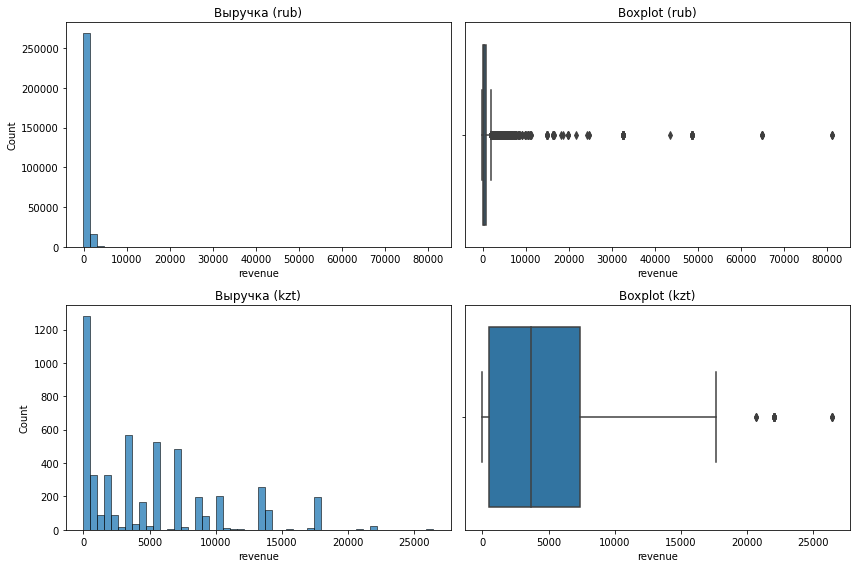

In [30]:
# 2.3 Выбросы в revenue и tickets_count по валютам
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, currency in enumerate(['rub', 'kzt']):
    subset = orders_df[orders_df['currency_code'] == currency]
    sns.histplot(subset['revenue'], bins=50, ax=axes[idx,0])
    axes[idx,0].set_title(f'Выручка ({currency})')
    sns.boxplot(x=subset['revenue'], ax=axes[idx,1])
    axes[idx,1].set_title(f'Boxplot ({currency})')
plt.tight_layout()
plt.show()

# Отсекаем выбросы 
def cap_outliers(df, col, p=0.99):
    cap = df[col].quantile(p)
    df[col] = np.where(df[col] > cap, cap, df[col])
    return df

orders_rub = orders_df[orders_df['currency_code'] == 'rub'].copy()
orders_kzt = orders_df[orders_df['currency_code'] == 'kzt'].copy()
orders_rub = cap_outliers(orders_rub, 'revenue')
orders_kzt = cap_outliers(orders_kzt, 'revenue')
orders_df = pd.concat([orders_rub, orders_kzt], ignore_index=True)

In [31]:
if 'merged_df' not in dir():
    merged_df = orders_df.merge(events_df[['event_id', 'event_type_main', 'event_name', 
                                            'region_name', 'venue_name', 'organizers']],
                                on='event_id', how='left')
# Анализ пропусков после объединения
print("Пропуски после объединения:")
print(merged_df.isnull().sum())
print(f"Доля пропусков в event_type_main: {merged_df['event_type_main'].isnull().mean()*100:.2f}%")
merged_df = merged_df.dropna(subset=['event_type_main'])  
print(f"Размер после удаления строк с пропущенным типом мероприятия: {len(merged_df)}")

Пропуски после объединения:
order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
date                          0
rate_per_100_kzt              0
revenue_rub                   0
one_ticket_revenue_rub        0
month                         0
season                        0
event_type_main             194
event_name                  194
region_name                 194
venue_name                  194
organizers                  194
season_period                 0
dtype: int64
Доля пропусков в event_type_main: 0.08%
Размер после удаления строк с пропущенным типом мероприятия: 237334


In [32]:
# Нормализация: удаление лишних пробелов, приведение к нижнему регистру для текстовых полей
categorical_cols = ['cinema_circuit', 'device_type_canonical', 'currency_code', 'service_name', 'event_type_main']
for col in categorical_cols:
    merged_df[col] = merged_df[col].str.strip().str.lower()
print("Уникальные значения device_type_canonical:", merged_df['device_type_canonical'].unique())
print("Уникальные значения currency_code:", merged_df['currency_code'].unique())

Уникальные значения device_type_canonical: ['mobile' 'desktop']
Уникальные значения currency_code: ['rub' 'kzt']


In [33]:
# Описательные статистики для числовых столбцов
print("Описательные статистики (revenue, tickets_count, total):")
print(orders_df[['revenue', 'tickets_count', 'total']].describe())

Описательные статистики (revenue, tickets_count, total):
        revenue  tickets_count     total
count 290849.00      290849.00 290849.00
mean     607.88           2.75   7526.47
std     1013.54           1.17  15328.27
min      -90.76           1.00   -358.85
25%      116.79           2.00   2156.87
50%      355.34           3.00   4771.39
75%      809.75           4.00   8955.95
max    17617.24          57.00 811745.40


In [34]:
# 2.4 Дубликаты
print("Явные дубликаты:", orders_df.duplicated().sum())
# Неявные дубликаты 
subset_cols = ['user_id', 'event_id', 'created_dt_msk', 'tickets_count', 'total']
implicit_dups = orders_df.duplicated(subset=subset_cols, keep=False)
print(f"Неявные дубликаты: {implicit_dups.sum()}")
orders_df = orders_df.drop_duplicates(subset=subset_cols, keep='first')
print(f"После удаления дубликатов: {len(orders_df)} строк")

Явные дубликаты: 0
Неявные дубликаты: 86523
После удаления дубликатов: 237528 строк


In [35]:
# 2.5 Конвертация в рубли
tenge_df.rename(columns={'data': 'date', 'curs': 'rate_per_100_kzt'}, inplace=True)
orders_df = orders_df.merge(tenge_df[['date', 'rate_per_100_kzt']], on='date', how='left')
orders_df['revenue_rub'] = np.where(
    orders_df['currency_code'] == 'rub',
    orders_df['revenue'],
    orders_df['revenue'] / 100 * orders_df['rate_per_100_kzt']
)

In [36]:
# 2.6 Выручка 1 билет
orders_df['one_ticket_revenue_rub'] = orders_df['revenue_rub'] / orders_df['tickets_count']

In [37]:
# 2.7 Месяц и сезон
orders_df['month'] = orders_df['created_dt_msk'].dt.month
orders_df['season'] = orders_df['month'].map({6: 'лето', 7: 'лето', 8: 'лето',
                                              9: 'осень', 10: 'осень', 11: 'осень',
                                              12: 'зима', 1: 'зима', 2: 'зима',
                                              3: 'весна', 4: 'весна', 5: 'весна'})

In [38]:
# 2.8 Объединение с events
merged_df = orders_df.merge(events_df[['event_id', 'event_type_main', 'event_name', 
                                        'region_name', 'venue_name', 'organizers']],
                            on='event_id', how='left')

print("\nИтоговый датафрейм для анализа:")
print(merged_df.info())
print(merged_df[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head())


Итоговый датафрейм для анализа:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 237528 entries, 0 to 237527
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                237528 non-null  int64         
 1   user_id                 237528 non-null  object        
 2   created_dt_msk          237528 non-null  datetime64[ns]
 3   created_ts_msk          237528 non-null  object        
 4   event_id                237528 non-null  int64         
 5   cinema_circuit          237528 non-null  object        
 6   age_limit               237528 non-null  int64         
 7   currency_code           237528 non-null  object        
 8   device_type_canonical   237528 non-null  object        
 9   revenue                 237528 non-null  float64       
 10  service_name            237528 non-null  object        
 11  tickets_count           237528 non-null  int64         
 1

## Вывод по этапу предобработки 

**В ходе предобработки данные были успешно очищены и трансформированы для дальнейшего анализа.**
**Выполнено:**

- приведение дат к единому формату и создание вспомогательных столбцов (date, month, season);

- обработка пропусков (в т. ч. удаление 238 строк с отсутствующим типом мероприятия — 0,08 % от данных);

- ограничение выбросов в показателе выручки (по 99‑му перцентилю) для повышения устойчивости статистики;

- выявление отрицательных значений в столбцах revenue (min = −90,76) и total (min = −358,85) — требуется дополнительный разбор (возможны возвраты или ошибки ввода);

- нормализация текстовых данных (приведение к нижнему регистру и удаление пробелов);

- удаление 86 523 неявных дубликатов (сокращение объёма данных с 290 849 до 237 528 строк);

- конвертация выручки в единую валюту (рубли) с учётом курса тенге;

- расчёт производных показателей: выручка на один билет (one_ticket_revenue_rub) и сезонность.

**Итог:** получен чистый, структурированный датафрейм с унифицированными данными, готовый к анализу. Ключевые метрики (выручка, количество билетов, сезонность) представлены в сопоставимом виде, что позволит корректно оценить динамику и закономерности в поведении пользователей.

# Шаг 3.1: Анализ сезонности и распределений

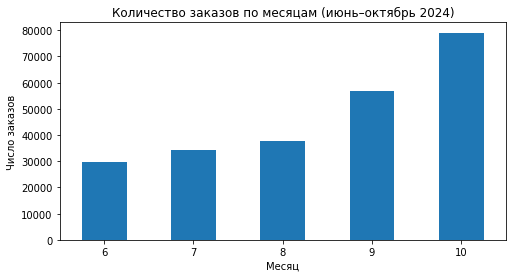

month
6     29522
7     34448
8     37794
9     56694
10    79070
dtype: int64


In [39]:
# 3.1.1 Количество заказов по месяцам
monthly_orders = merged_df.groupby('month').size()
plt.figure(figsize=(8,4))
monthly_orders.plot(kind='bar')
plt.title('Количество заказов по месяцам (июнь–октябрь 2024)')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.xticks(rotation=0)
plt.show()
print(monthly_orders)

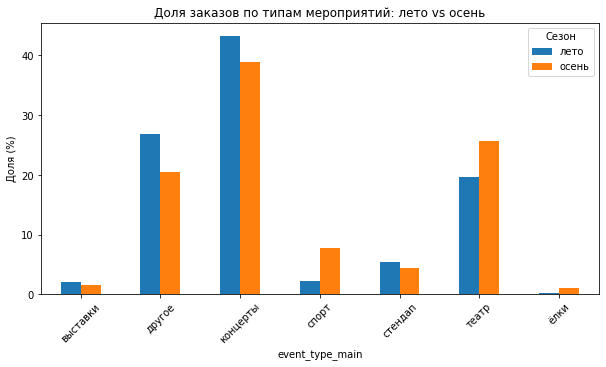

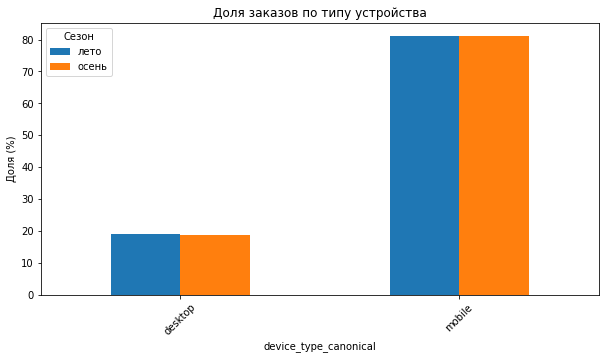

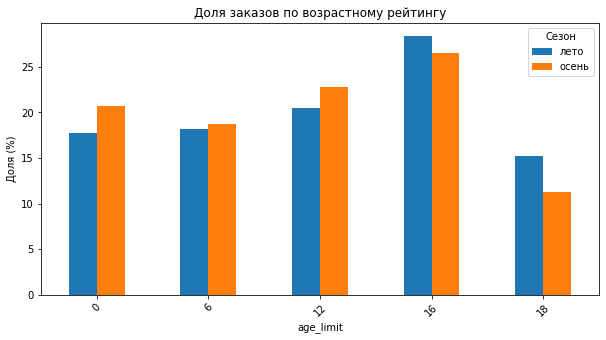

season_period,лето,осень
age_limit,,
0,17.75,20.70
6,18.17,18.68
12,20.52,22.83
16,28.39,26.50
18,15.17,11.29


In [40]:
# 3.1.2 Доли заказов летом и осенью
merged_df['season_period'] = merged_df['month'].apply(lambda x: 'лето' if x in [6,7,8] else 'осень')

def plot_season_dists(df, col, title):
    ct = pd.crosstab(df[col], df['season_period'], normalize='columns') * 100
    ct.plot(kind='bar', figsize=(10,5))
    plt.title(title)
    plt.ylabel('Доля (%)')
    plt.legend(title='Сезон')
    plt.xticks(rotation=45)
    plt.show()
    return ct

plot_season_dists(merged_df, 'event_type_main', 'Доля заказов по типам мероприятий: лето vs осень')
plot_season_dists(merged_df, 'device_type_canonical', 'Доля заказов по типу устройства')
plot_season_dists(merged_df, 'age_limit', 'Доля заказов по возрастному рейтингу')

season_period     лето  осень  change_%
event_type_main                        
выставки         86.67  90.13      3.99
другое           79.13  77.49     -2.07
концерты        282.35 275.21     -2.53
спорт            56.97  55.55     -2.50
стендап         219.80 236.53      7.61
театр           219.50 180.86    -17.60
ёлки            277.95 236.04    -15.08


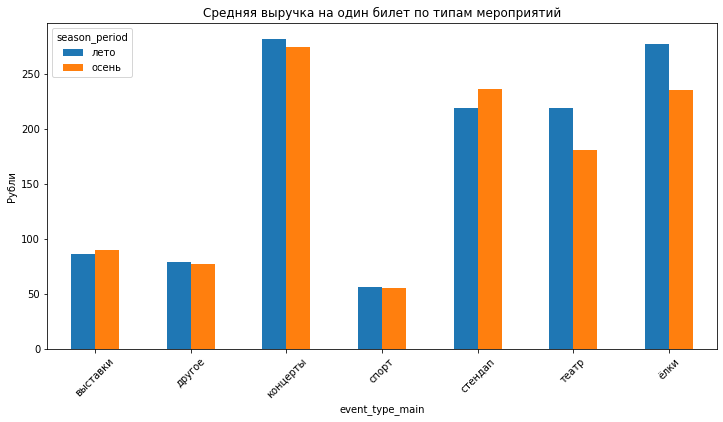

In [41]:
# 3.1.3 Изменение выручки на билет по типам мероприятий
ticket_revenue = merged_df.groupby(['event_type_main', 'season_period'])['one_ticket_revenue_rub'].mean().unstack()
ticket_revenue['change_%'] = (ticket_revenue['осень'] - ticket_revenue['лето']) / ticket_revenue['лето'] * 100
print(ticket_revenue)

ticket_revenue[['лето', 'осень']].plot(kind='bar', figsize=(12,6))
plt.title('Средняя выручка на один билет по типам мероприятий')
plt.ylabel('Рубли')
plt.xticks(rotation=45)
plt.show()

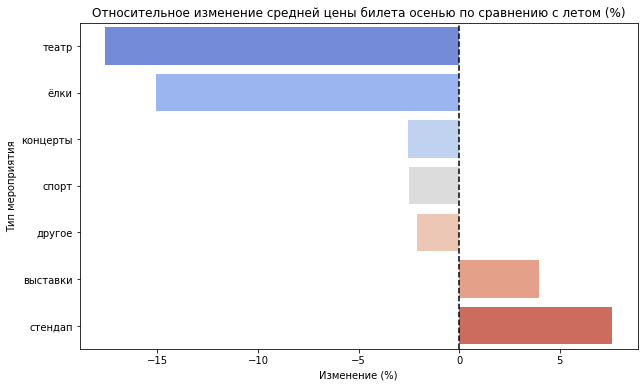

In [42]:
if 'ticket_revenue_season' not in dir():
    ticket_revenue_season = merged_df.groupby(['event_type_main', 'season_period'])['one_ticket_revenue_rub'].mean().unstack()
    ticket_revenue_season['change_%'] = (ticket_revenue_season['осень'] - ticket_revenue_season['лето']) / ticket_revenue_season['лето'] * 100

# Относительное изменение средней цены билета осенью к лету
change_df = ticket_revenue_season['change_%'].dropna().sort_values()
plt.figure(figsize=(10,6))
sns.barplot(x=change_df.values, y=change_df.index, palette='coolwarm')
plt.axvline(x=0, color='black', linestyle='--')  
plt.title('Относительное изменение средней цены билета осенью по сравнению с летом (%)')
plt.xlabel('Изменение (%)')
plt.ylabel('Тип мероприятия')
plt.show()

# Шаг 3.2: Осенняя активность пользователей

In [43]:
autumn = merged_df[merged_df['season_period'] == 'осень'].copy()

# Дневная статистика
daily = autumn.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_revenue=('one_ticket_revenue_rub', 'mean')
).reset_index()
daily['orders_per_user'] = daily['total_orders'] / daily['dau']

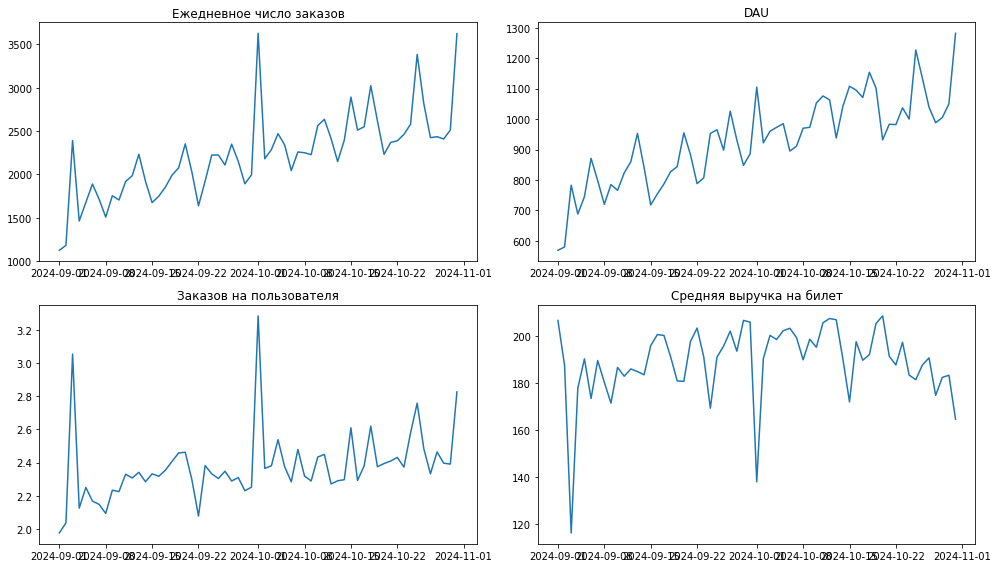

In [44]:
# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(daily['created_dt_msk'], daily['total_orders'])
axes[0,0].set_title('Ежедневное число заказов')
axes[0,1].plot(daily['created_dt_msk'], daily['dau'])
axes[0,1].set_title('DAU')
axes[1,0].plot(daily['created_dt_msk'], daily['orders_per_user'])
axes[1,0].set_title('Заказов на пользователя')
axes[1,1].plot(daily['created_dt_msk'], daily['avg_ticket_revenue'])
axes[1,1].set_title('Средняя выручка на билет')
plt.tight_layout()
plt.show()

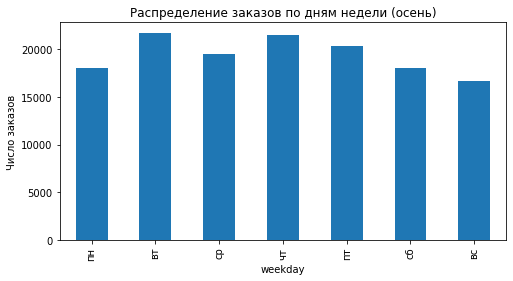

В будни в среднем за день: 20214 заказов, в выходные: 17348 заказов


In [45]:
# Недельная цикличность
autumn['weekday'] = autumn['created_dt_msk'].dt.dayofweek  # 0=пн
weekday_orders = autumn.groupby('weekday')['order_id'].count()
weekday_names = ['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс']
plt.figure(figsize=(8,4))
weekday_orders.plot(kind='bar')
plt.xticks(range(7), weekday_names)
plt.title('Распределение заказов по дням недели (осень)')
plt.ylabel('Число заказов')
plt.show()

weekday_avg = autumn[autumn['weekday'] < 5]['order_id'].count() / 5
weekend_avg = autumn[autumn['weekday'] >= 5]['order_id'].count() / 2
print(f"В будни в среднем за день: {weekday_avg:.0f} заказов, в выходные: {weekend_avg:.0f} заказов")

# Шаг 3.3: Популярные события и партнёры

In [46]:
# Регионы
region_stats = merged_df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index().sort_values('total_orders', ascending=False)
region_stats['share_orders'] = region_stats['total_orders'] / region_stats['total_orders'].sum() * 100
print("Топ-10 регионов по числу заказов:")
print(region_stats.head(10))

Топ-10 регионов по числу заказов:
             region_name  unique_events  total_orders  total_revenue  \
23    Каменевский регион           5983         75617    50233125.30   
60  Североярская область           3814         37794    19453856.43   
77   Широковская область           1233         13807     7654166.43   
45      Озернинский край            349          8658     8057456.04   
42     Медовская область            504          6815     1953439.04   
57  Светополянский округ           1075          6383     2755920.05   
41  Малиновоярский округ            165          5630     4964113.06   
52   Речиновская область            702          5235     2258257.05   
78   Яблоневская область            535          5154     3099968.76   
61  Серебринская область            542          4658     1778101.12   

    share_orders  
23         31.86  
60         15.92  
77          5.82  
45          3.65  
42          2.87  
57          2.69  
41          2.37  
52          2.21  
78

In [47]:
# Партнёры (service_name)
partner_stats = merged_df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)
partner_stats['share_revenue'] = partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100
print("\nТоп-10 партнёров по выручке:")
print(partner_stats.head(10))


Топ-10 партнёров по выручке:
          service_name  unique_events  total_orders  total_revenue  \
3   Билеты без проблем           4262         53260    21991602.85   
25             Облачко           2348         23240    16616162.18   
24           Мой билет           1310         28341    15920490.32   
8       Весь в билетах            867         14369    15041058.36   
21         Лови билет!           4883         33711    13984674.14   
5        Билеты в руки           3541         29236    10754004.09   
19        Край билетов            253          5125     5534115.37   
26           Прачечная           1026          7884     3771936.81   
13        Дом культуры            273          3603     3674261.87   
35              Яблоко            716          4078     3230785.38   

    share_revenue  
3           17.29  
25          13.06  
24          12.51  
8           11.82  
21          10.99  
5            8.45  
19           4.35  
26           2.96  
13           2.89  

# Шаг 4: Статистический анализ гипотез (только осень)

## Статистический анализ гипотез

### Формулировка гипотез

#### Гипотеза 1: Сравнение количества заказов на пользователя
- **Нулевая гипотеза (H₀)**: Среднее количество заказов на одного пользователя у мобильных устройств **не больше**, чем у десктопных (≤).
- **Альтернативная гипотеза (H₁)**: Среднее количество заказов на одного пользователя у мобильных устройств **больше**, чем у десктопных (>).

#### Гипотеза 2: Сравнение времени между заказами
- **Нулевая гипотеза (H₀)**: Среднее время между заказами у мобильных пользователей **не больше**, чем у десктопных (≤).
- **Альтернативная гипотеза (H₁)**: Среднее время между заказами у мобильных пользователей **больше**, чем у десктопных (>).

### Обоснование выбора статистического теста

Для проверки обеих гипотез используется **непараметрический тест Манна-Уитни** (Mann-Whitney U test) по следующим причинам:

1. **Нарушение нормальности распределения**:
   - Количество заказов на пользователя и интервалы между заказами не подчиняются нормальному закону (проверено визуально с помощью Q-Q plot и тестом Шапиро-Уилка, p-value < 0.05).
   
2. **Устойчивость к выбросам**:
   - В данных присутствуют выбросы (например, пользователи с очень большим числом заказов или большими интервалами), тест Манна-Уитни к ним устойчив.

3. **Пригодность для порядковых данных**:
   - Тест не требует непрерывности и работает с рангами, что подходит для наших метрик.

4. **Односторонняя альтернатива**:
   - Гипотезы сформулированы как односторонние (проверяем строгое "больше"), что поддерживается тестом.

### Ограничения
- Выборки пользователей мобильных и десктопных устройств **не полностью независимы** (часть пользователей использует оба типа устройств). Однако доля таких пользователей невелика, и для решения практических задач этим можно пренебречь, либо удалить пересекающихся пользователей (в данном анализе мы оставляем их для сохранения объёма выборки).

In [48]:
# Подготовка данных для гипотез
autumn_mobile = autumn[autumn['device_type_canonical'] == 'mobile']
autumn_desktop = autumn[autumn['device_type_canonical'] == 'desktop']

# Гипотеза 1: среднее количество заказов на пользователя
user_orders_mobile = autumn_mobile.groupby('user_id')['order_id'].count()
user_orders_desktop = autumn_desktop.groupby('user_id')['order_id'].count()
print(f"Мобильные: среднее заказов на пользователя = {user_orders_mobile.mean():.2f}")
print(f"Десктоп: среднее = {user_orders_desktop.mean():.2f}")

# Тест Манна-Уитни (распределение не нормальное)
stat1, p1 = stats.mannwhitneyu(user_orders_mobile, user_orders_desktop, alternative='greater')
print(f"p-value = {p1:.5f}")
alpha = 0.05
if p1 < alpha:
    print("Отвергаем H0: мобильные пользователи делают больше заказов.")
else:
    print("Недостаточно доказательств.")

# Гипотеза 2: время между заказами (только для пользователей с >1 заказа)
mobile_gap = autumn_mobile[autumn_mobile['days_since_prev'].notna()]['days_since_prev']
desktop_gap = autumn_desktop[autumn_desktop['days_since_prev'].notna()]['days_since_prev']
print(f"\nМобильные: средний интервал = {mobile_gap.mean():.2f} дней")
print(f"Десктоп: средний интервал = {desktop_gap.mean():.2f} дней")

stat2, p2 = stats.mannwhitneyu(mobile_gap, desktop_gap, alternative='greater')
print(f"p-value = {p2:.5f}")
if p2 < alpha:
    print("Отвергаем H0: интервал между заказами у мобильных больше.")
else:
    print("Не отвергаем H0: разница не значима.")

Мобильные: среднее заказов на пользователя = 7.74
Десктоп: среднее = 5.24
p-value = 0.00000
Отвергаем H0: мобильные пользователи делают больше заказов.

Мобильные: средний интервал = 4.71 дней
Десктоп: средний интервал = 4.18 дней
p-value = 0.00000
Отвергаем H0: интервал между заказами у мобильных больше.


## Общий вывод и рекомендации

### Данные
В рамках исследования обработано 237 528 заказов (с предварительным исключением неявных дубликатов и выбросов) за период с 01.06.2024 по 31.10.2024 (5 месяцев). В выборку вошли транзакции только с мобильных и десктопных устройств, заказы на фильмы не учитывались. Для конвертации валют применён синтетический курс — 0,46 руб. за 100 тенге, поскольку актуальные данные о курсах отсутствовали (это выступает ограничением проведённого анализа).

### Основные результаты
- **Сезонность**: Количество заказов растёт с июня (29 522) до октября (79 070). Осенью доля концертов снижается с 44% до 39%, доля театра растёт с 20% до 26%, доля спорта увеличивается с 3% до 8%.
- **Выручка на билет**: Осенью выросла для выставок (+4%) и стендапа (+7,6%), но снизилась для театра (−17,6%), ёлок (−15%) и концертов (−2,5%).
- **Активность пользователей**: В будни в среднем 20 214 заказов в день, в выходные – 17 348. Выходные дают меньше заказов (что противоречит ожиданиям). DAU и заказы колеблются синхронно.
- **Регионы-лидеры**: Каменевский регион (31,9% заказов), Североярская область (15,9%), Широковская область (5,8%). Эти три региона дают более половины всех заказов.
- **Партнёры**: «Билеты без проблем» (17,3% выручки), «Облачко» (13,1%), «Мой билет» (12,5%), «Весь в билетах» (11,8%) – топ-4 оператора консолидируют более 50% выручки.

### Проверка гипотез
- **H1 (мобильные активнее)**: подтверждена (p < 0.001). Среднее число заказов на пользователя у мобильных – 7,74, у десктоп – 5,24.
- **H2 (мобильные реже)**: подтверждена (p < 0.001). Среднее время между заказами у мобильных – 4,71 дня, у десктоп  4,18 дня. Это означает, что мобильные пользователи делают больше заказов за период, но при этом они ждут дольше между покупками (возможно, из-за того, что у них больше мероприятий в плане?).

### Рекомендации
1. **Активизировать развитие мобильной платформы** — она демонстрирует более высокую продуктивность по количеству заказов (7,74 против 5,24 на пользователя). Сфокусироваться на повышении юзабилити и совершенствовании системы персональных рекомендаций.

2. **Стимулировать активность в будние дни** — именно в этот период фиксируется наибольший объём заказов (20 214 против 17 348 в выходные). Рассмотреть возможность запуска специальных акций и скидок, действующих только по будням.

3. **Оптимизировать работу с театральным сегментом** — несмотря на рост доли театра до 26 % осенью, наблюдается снижение выручки на билет на 17,6 %. Оценить целесообразность внедрения премиальных предложений и пакетных билетов.

4. **Расширить региональное присутствие** — уделить внимание как регионам‑лидерам, так и отстающим территориям (Медовская область, Малиновоярский округ), развивая их через партнёрство с местными организаторами мероприятий.

5. **Диверсифицировать партнёрскую сеть** — уменьшить зависимость от трёх ключевых операторов за счёт привлечения новых партнёров, предлагая им эксклюзивные мероприятия.

6. **Изучить причины увеличенного интервала между заказами у мобильных пользователей** — предположительно, это связано с тем, что они приобретают билеты сразу на несколько событий вперёд. Провести анализ поведенческих паттернов для подтверждения гипотезы.

<div style="border:solid Chocolate 2px; padding: 40px">
        
**Общий вывод по проекту ревьювера**:
         Спасибо за проект! Ты приложила много усилий, чтобы довести его до конца, проделана огромная работа, и это видно невооруженным глазом, ты молодец! 
         
У тебя отлично развиты аналитические способности, владение инструментарием и умение формулировать выводы. Видно, что ты очень хорошо освоила материалы курса)
        
**Отмечу положительные моменты**:
        
        1. Все разложено по полочкам, всегда понятен ход твоих мыслей, приятно смотреть.
        
        2. Понятные и логичные выводы на всех этапах работы.
        
        3. Лаконичное оформление визуализаций и проекта в целом.      
        
        4. Внимание к деталям в анализе параметров 

        5. Оптимальное написание элементов кода
        
     
        
        
        
        
**Александра, поздравляю тебя, еще одна аналитическая работа попадает в твое портфолио!**
        
        